<a href="https://colab.research.google.com/github/mikeogunmakin/study/blob/main/02%20machine%20learning/machine%20learning%20scientist%20in%20python/machine_learning_scientist_in_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Supervised Learning with Scikit-Learn**

## **Classification**

### **Machine Learning with Scikit-learn**

**What is Machine Learing?** Machine learning is the process whereby computers learn to make decisions from data without being explicitly programmed.
<br>
<br>
For example, learning to predict whether an email is spam or not spam given its content and sender. Or learning to cluster books into different categories based on the words they contain, then assigning any new book to one of the existing clusters.

**What is unsupervised learning?** Unsupervised learning is the process of uncovering hidden patterns and structures from unlabeled data. For example, a business may wish to group its customers into distinct categories based on their purchasing behavior without knowing in advance what these categories are.



**What is supervised learning?** Supervised learning is a type of machine learning where the values to be predicted are already known, and a model is built with the aim of accurately predicting values of previously unseen data.Supervised learning uses features to predict the value of a target variable, such as predicting a basketball player's position based on their points per game

**What are the types of supervised learning?** There are two types of supervised learning. Classification is used to predict the label, or category, of an observation. For example, we can predict whether a bank transaction is fraudulent or not. As there are two outcomes here - a fraudulent transaction, or non-fraudulent transaction, this is known as binary classification. Regression is used to predict continuous values. For example, a model can use features such as number of bedrooms, and the size of a property, to predict the target variable, price of the property.

**What are the different naming conventions for features and target variables?**

- feature = predictor variable = independent variable
- Target variable = response variable = dependent variable

**What are the requirements for performing supervised learning in Scikit-Learn?**

- No missing values
- Data must be in numeric format
- Data stored in pandas dataframe or NumPy array


**What is the syntax workflow syntax?** scikit-learn follows the same syntax for all supervised learning models, which makes the workflow repeatable. it's as follows

1. import model from Scikit-learn Module
2. Create and instantiate the model
3. Fit the model to X and y
4. Use predict method to get predictions to unseen data of X





```
#1
From sklearn.module import Model

#2
model = Model()

#3
model.fit(X,y)

#4
predictions = model.predict(X_new)

```



### **The Classification Challenge**

**challenge:** to predict the labels of unseen data.

What are the steps in classifying labels of unseen data? There are four steps:
1. Build a model - First, we build a classifier,
2. Model learns from the labelled data we pass to it
3. Pass unlabelled data to the model as input
4. Model predicts the labels of the unseen data.


The labeled data is the training data.

K-Nearest Neighbors (KNN) is algorithm is an algorithm to predict the label of any data point by looking at the k, for example, three, closest labeled data points and getting them to vote on what label the unlabeled observation should have. KNN uses majority voting, which makes predictions based on what label the majority of nearest neighbors have.

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

churn_df = pd.read_csv('/content/drive/MyDrive/datasets/telecom_churn_clean.csv')


y = churn_df["churn"].values
X = churn_df[["account_length", "customer_service_calls"]].values

# Create a KNN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the data
knn.fit(X, y)


KNeighborsClassifier(n_neighbors=6)

In [ ]:

X_new = np.array([[30.0, 17.5],
                  [107.0, 24.1],
                  [213.0, 10.9]])

y_pred = knn.predict(X_new)


print('Predictions: {}'.format(y_pred))

Predictions: [0 1 0]


 Note: As k increases, the decision boundary is less affected by individual observations, reflecting a simpler model. Simpler models are less able to detect relationships in the dataset, which is known as underfitting. In contrast, complex models can be sensitive to noise in the training data, rather than reflecting general trends. This is known as overfitting.

 - larger K = less complex model = can cause underfitting
 - smaller K = more complex model = can lead to overfitting

 we can interpret K by using a model complexity curve.

side note: how to visualuse the results of a model?

### **Measuring Model Performance**

Now we can make predictions using a classifier, but how do we know if the model is making correct predictions? We can evaluate its performance!
<br>
<br>
In classification, accuracy is a commonly-used metric. Accuracy is the number of correct predictions divided by the total number of observations.
<br>
<br>
$$
\frac{\text{correct predictions}}{\text{total predictions}}
$$
<br>

How do we measure accuracy? We could compute accuracy on the data used to fit the classifier. However, as this data was used to train the model, performance will not be indicative of how well it can generalize to unseen data, which is what we are interested in!
<br>
<br>
It is common to split data into a training set and a test set. We fit the classifier using the training set,then we calculate the model's accuracy against the test set's labels.
<br>
<br>
To do this, we import `train_test_split` from `sklearn.model_selection`. We call train_test_split, passing our features and targets. We commonly use 20-30% of our data as the test set.

In [ ]:
# Import the module
from sklearn.model_selection import train_test_split

X = churn_df.drop('churn', axis=1).values
y = churn_df['churn'].values

# Split into training and test sets
X_train,X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size=0.20,
                                                   random_state=42,
                                                   stratify=y)

# Instantiate and Fit the classifier to the training data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

#print the accuracy
print(knn.score(X_test, y_test))


0.8545727136431784


In [ ]:
# Create neighbors
neighbors = np.arange(1, 13)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:

	# Set up a KNN Classifier
	knn = KNeighborsClassifier(n_neighbors=neighbor)

	# Fit the model
	knn.fit(X_train, y_train)

	# Compute accuracy
	train_accuracies[neighbor] = knn.score(X_train, y_train)
	test_accuracies[neighbor] = knn.score(X_test, y_test)

print(neighbors, '\n', train_accuracies, '\n', test_accuracies)

[ 1  2  3  4  5  6  7  8  9 10 11 12] 
 {np.int64(1): 1.0, np.int64(2): 0.8885971492873218, np.int64(3): 0.8994748687171793, np.int64(4): 0.8750937734433608, np.int64(5): 0.878469617404351, np.int64(6): 0.8660915228807202, np.int64(7): 0.8705926481620405, np.int64(8): 0.8615903975993998, np.int64(9): 0.86384096024006, np.int64(10): 0.858589647411853, np.int64(11): 0.8604651162790697, np.int64(12): 0.8574643660915229} 
 {np.int64(1): 0.7856071964017991, np.int64(2): 0.8470764617691154, np.int64(3): 0.8320839580209896, np.int64(4): 0.856071964017991, np.int64(5): 0.8545727136431784, np.int64(6): 0.8590704647676162, np.int64(7): 0.8605697151424287, np.int64(8): 0.8620689655172413, np.int64(9): 0.863568215892054, np.int64(10): 0.8605697151424287, np.int64(11): 0.8605697151424287, np.int64(12): 0.8605697151424287}


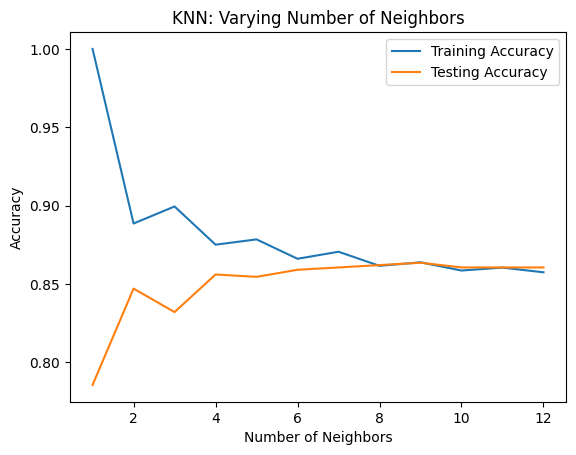

In [ ]:
# Add a title
plt.title("KNN: Varying Number of Neighbors")

# Plot training accuracies
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")

# Plot test accuracies
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

# Display the plot
plt.show()

## **Regression**

### Introduction to Regression

Note: features must be formatted as a two-dimensional array to be accepted by scikit-learn. To convert a single column X variable we apply NumPy's `.reshape` method, passing minus one followed by one.

In [10]:
import pandas as pd
import numpy as np

sales_df = pd.read_csv('/content/drive/MyDrive/datasets/advertising_and_sales_clean.csv')


# Create X from the radio column's values and reshape
X = sales_df['radio'].values.reshape(-1,1)

# Create y from the sales column's values
y = sales_df['sales'].values


# Check the shape of the features and targets
print(X.shape, y.shape)

(4546, 1) (4546,)


In [9]:
# Import LinearRegression
from sklearn.linear_model import LinearRegression

# Create the model
reg = LinearRegression()

# Fit the model to the data
reg.fit(X,y)

# Make predictions
predictions = reg.predict(X)

print(predictions[:5])

[ 95491.17119147 117829.51038393 173423.38071499 291603.11444202
 111137.28167129]


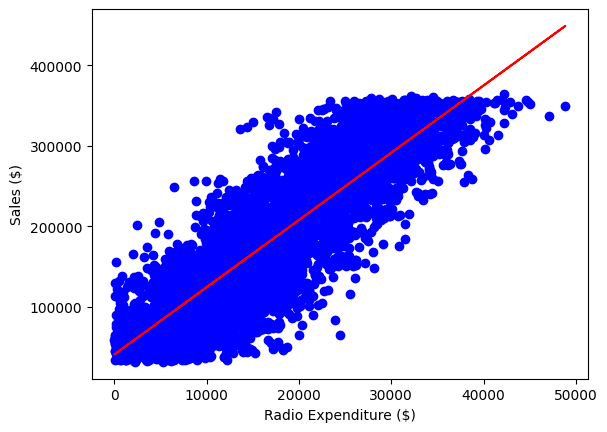

In [11]:
# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(X, y, color="blue")

# Create line plot
plt.plot(X, predictions, color="red")
plt.xlabel("Radio Expenditure ($)")
plt.ylabel("Sales ($)")

# Display the plot
plt.show()

### The basics of linear regression